<a href="https://colab.research.google.com/github/varadasantosh/deep-learning-notes/blob/tensorflow/transformers/Attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evolution of Attention Mechanism

Attention was firts introduced as part of seq-to-seq (Encoder-Decoder) models in the domain of Neural Machine Translation to translate text from one language to other language. Initial Architectures of encoder-decoder models were composed of encoder and decoder both are RNN's, it is also possible to combine both simple RNN as part of encoder and GRU or LSTM for decoder , encoder takes sentence in source language as input and generates context vector of fixed lentgh , which would be passed as input to Decoder , Decoder takes the context vector and tries to map it to corresponding word or text in target language, this has few limitations as the single context vector generated by the encoder RNN could not capture the entire meaning of the sentence in source language which resulted less accurate results, especially as the length of the sequence grows the accuracy drops.

Inorder to overcome the issues of initial seq-to-seq models, researchers came up with an approach to capture all hidden states of encoder pass them to decoder to capture the meaning or context , but now the challenge is to know which hidden state could be contributing more to find the next word in target language, this is not simple as the source and target languages have different semantics , researchers came up with an approach to build alignment model (Single Layer Feed Forward Neural Network) that takes hidden state of previous decoder timestep $S_{i-
1}$ and encoder hidden state $h_{j}$ vector to build context vector $C_{t}$ using alignment model , the alignment model computes the compatability scores between the previous decoder hidden state and each hidden state of encoder , thus computed compatability scores are passed through softmax function to normalize the scores, these scores are multiplied with each hidden state
of the encoder to calculate the weighted scores of the encoder hidden states, all these weighted hidden states are added which results in context vector this is passed as one of the inputs the Decoder timestep $S_{i}$ along with hidden state of previous decoder timestep, **this lays the foundation for the Attention Mechanism, the attention that we discussed is Bahdanau Attention
this is also called Additive attention as we are adding all the context vectors to calculate the alignment scores**, this triggered further improvements and `Loung Attention` proposed different ways to calculate alginment scores to calculate the relevance between each hiddent vector of encoder and current decoder state, as part of Loung attention they also managed to avoid
the alginment model, which reduces the number of parameters to be trained. Below is the reference picture of how Bahdanu Attention works

  ![image](https://github.com/user-attachments/assets/ddd1c4a0-165c-4fc7-a984-d24ea680cb90)

# Attention in Transformers


The above mentioned attentions **Bahdanau & Luong**  paved way for attention in Transformers, there are few disadvantages with the prior Attention mechanism major one being both of them are
sequential in nature, as we process one token after the other this makes training process tedious and time taking, as we see the birth the of Large Language models that are trained on
Billions of tokens, this would not have been possible without Self Attention which calculates these Attention scores in parallel which were referred as Alignment scores in Bahdanau & Loung
Attentions, to make this parallel processing possible Self Attention follows below steps.

  1. Tokenize Sentence - Breaks the sentence into tokens
  2. Generate Embeddings for the tokens
  3. Pass the Embeddings tokens through different Linear Layers to generate Q,K,V & O matrices, each linear layer has its corresponding weight matrices, $W_{Q}$ , $W_{K}$ $W_{V}$ & $W_{O}$
      these weights are learned through the training process.

      - X * $W_{Q}$ = Q - Query Vector
      - X * $W_{K}$ = K - Key Vector  
      - X * $W_{V}$ = V - Value Vector
      - X * $W_{O}$ = O - Output Vector

    **Dimensions**
  
    - X -> T  * $d_{model}$
    - $W_{Q}$ -> $d_{model}$ * $d_{k}$
    - $W_{K}$ -> $d_{model}$ * $d_{k}$
    - $W_{V}$ -> $d_{model}$ * $d_{k}$
    - $W_{O}$ -> $d_{model}$ * $d_{k}$

    - T - Sequence Length
    - $d_{model}$  - Length of Embeddings
    - $d_{k}$ - Output dimensions of $W_{Q}$,$W_{K}$ & $W_{V}$, this can be
      same as $d_{model}$ as well

  4. Calculate the Scaled Dot Product Between Q (Query) & K (Key) vectors to
     find how each token relates to other token,this is simialr to calculation of alignment scores in earlier Seq-to-Seq RNN models

     **Scaled Dot Product Attention**: -   $\left( \frac{QK^T}{\sqrt{d_k}} \right)$

        ![image](https://github.com/user-attachments/assets/25cd0ce2-7734-4ecf-b0f3-e33cce29cd78)

  5. Result of Scaled Dot Product Attention is passed through Softmax to
     normalize the attention scores
             
     **Normalize Attention Scores**:-  $\text{softmax}\left( \frac{QK^T}{\sqrt{d_k}} \right)$

  6. Multiply these Attention scores with $W_{V}$ to calculate the weighted attentions  
    

  7. Result of the Weighted attentions is thus multiplied by $W_{O}$ output projections.

     Below is the code snippet that explains above steps briefly, though this is not exactly what is being used in Transformer Architecture, as we use Multi Head Attention which we will discuss
     but this is the core of the  Attention calculation

       

# Implementation

Below is the code snippet that explains above steps briefly, most of Transformer Architectures use Multi Head Attention to calcualte the attention score, below gives an idea on how attention scores are calculated

In [3]:
import torch
import torch.nn as nn
from torch import Tensor


class Attention(nn.Module):


  def __init__(self, embedding_dim: int, attention_dim: int):
    super().__init__()
    torch.manual_seed(0)

    # Initialising weights
    self.wk = nn.Linear(embedding_dim, attention_dim, bias=False)
    self.wq = nn.Linear(embedding_dim, attention_dim, bias=False)
    self.wv = nn.Linear(embedding_dim, attention_dim, bias=False)

  def forward(self, embedded: Tensor) -> Tensor:
    # calculating Query, Key and Value
    q = self.wq(embedded)
    k = self.wk(embedded)
    v = self.wv(embedded)

    # calculating attention scores
    attn_score = q @ torch.transpose(k, -2, -1) / (k.shape[-1] ** 0.5) # [batch_size, num_words, num_words]

    # below 2 lines is for masking in decoder block
    upper_triangular  = torch.triu(attn_score, diagonal=1).bool()
    attn_score[upper_triangular] = float("-inf")

    # applying softmax
    attn_score_softmax = nn.functional.softmax(attn_score, dim = -1) # [batch_size, num_words, num_words]

    # getting weighted values by multiplying softmax of attention score with values
    weighted_values = attn_score_softmax @ v #

    return weighted_values

# Visualizing Self Attention using Llama Model

##Download the Llama Model from Hugging Face

In [1]:
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM
import torch

model_name= "meta-llama/Llama-3.2-3B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_attentions=True)

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/20.9k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

## Llama Model Architecture
 (Llama is Decoder only Transformer , hence we can see there are only 28 Decoder Layers, zero encoder layers)

In [2]:
print(model)

LlamaModel(
  (embed_tokens): Embedding(128256, 3072)
  (layers): ModuleList(
    (0-27): 28 x LlamaDecoderLayer(
      (self_attn): LlamaAttention(
        (q_proj): Linear(in_features=3072, out_features=3072, bias=False)
        (k_proj): Linear(in_features=3072, out_features=1024, bias=False)
        (v_proj): Linear(in_features=3072, out_features=1024, bias=False)
        (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
      )
      (mlp): LlamaMLP(
        (gate_proj): Linear(in_features=3072, out_features=8192, bias=False)
        (up_proj): Linear(in_features=3072, out_features=8192, bias=False)
        (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
        (act_fn): SiLU()
      )
      (input_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
      (post_attention_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
    )
  )
  (norm): LlamaRMSNorm((3072,), eps=1e-05)
  (rotary_emb): LlamaRotaryEmbedding()
)


## Tokenize the Input Sentence & Pass it through the Llama Model

In [3]:
import torch

text = "the financial bank is located on river bank"
inputs = tokenizer(text, return_tensors="pt").to("cuda")
token_ids = inputs.input_ids[0]
tokens = tokenizer.convert_ids_to_tokens(token_ids)
model = model.to("cuda")
with torch.no_grad():
    inputs = inputs.to("cuda")
    outputs = model(**inputs)

`torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to eager attention. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


Get The Attention Matrix from the Outputs, there are 28 Layers , we can see the below dimensions of the `attention_matrix` of length 28 & each layer's attention matrix is of shape (1,24,9,9) - This is because Llama Model has 24 Heads (This refers to Multi Head attention) and sequence length of tokens that we passed is of length 9 hence the dimension of each head is 9*9

In [6]:
attention_matrix = outputs.attentions
print(f"Number of Attention Matrices == Number of Layers:  {len(attention_matrix)}")
print(f"Shape of Each Attention Matrix {attention_matrix[0].shape}")

Number of Attention Matrices == Number of Layers:  28
Shape of Each Attention Matrix torch.Size([1, 24, 9, 9])


## Observe the Attention Scores

Get Attentions from final layer, calculate the avg attention scores across all heads and plot the heatmap to find relation ship, though from the below heatmap we can't find stronger
       contextual relation ship between tokens like financial & bank , river & bank we can see them when we go through individual heads of multihead attention, but one thing we can observe in
       the attention score heatmap is all the elements above diagonal are zero. This is because the Decoder part of model has casual attention which prevents each token from attending to future        tokens of the sequence, this is important as transformers do the self attention in parallel, where as in RNN the attention always sequentially , hence we don't step on to future
       tokens, in transformers this is not the case as we are processing all the tokens in parallel.

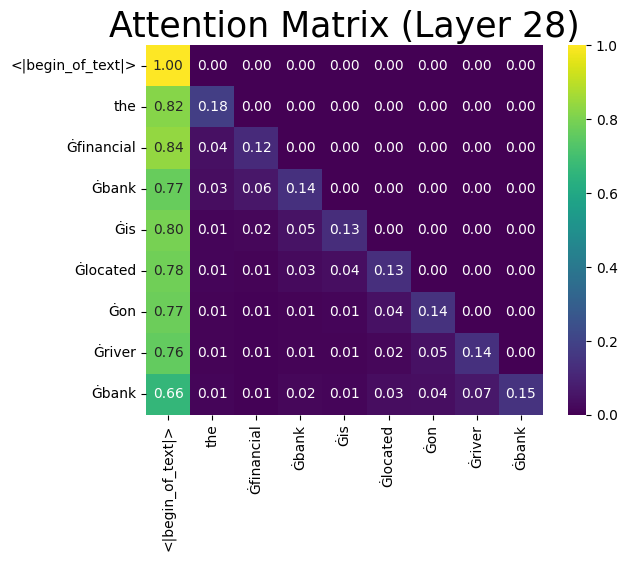

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
avg_attn =attention_matrix[27][0].mean(dim=0)
sns.heatmap(avg_attn.cpu(), cmap="viridis",annot=True,fmt=".2f",xticklabels=tokens,yticklabels=tokens )
plt.title(f"Attention Matrix (Layer 28)",fontdict={'fontsize':25})
plt.show()